In [1]:
from pathlib import Path
from datetime import datetime
from typing import Optional, Tuple, Dict

#from data.minbpe import BasicTokenizer as Tokenizer
from src.minbpe import RegexTokenizer as Tokenizer
from src.gpt import GPTLanguageModel

import matplotlib.pyplot as plt
import torch
torch.manual_seed(3647)
torch.set_float32_matmul_precision('high')
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
####
def now():
    return datetime.now().astimezone().strftime('%FT%T%:z')

def print_model_structure(model: nn.Module, indent: str = '') -> None:
    """
    Custom function to print model structure in a hierarchical format
    """
    for name, child in model.named_children():
        params = sum(p.numel() for p in child.parameters())
        print(f"{indent}├─ {name}: {child.__class__.__name__} ({params:,} parameters)")
        print_model_structure(child, indent + '│  ')

class TextDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int) -> None:
        self.data = data
        self.block_size = block_size

    def __len__(self) -> int:
        return len(self.data) - self.block_size

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        x = self.data[index:index + self.block_size]
        y = self.data[index + 1:index + self.block_size + 1]
        return x, y

def get_dataloaders(
        train_data: torch.Tensor,
        val_data: torch.Tensor,
        block_size: int,
        batch_size: int,
        device: torch.device,
) -> Tuple[DataLoader, DataLoader]:
    train_dataset = TextDataset(train_data.to(device), block_size)
    val_dataset = TextDataset(val_data.to(device), block_size)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, val_loader

In [3]:
####
tokenizer_dir = Path("data") / "tokenizer"

tokenizer = Tokenizer()
tokenizer.load(model_file=str(tokenizer_dir / "tokenizer.model"))

train_data = torch.load(tokenizer_dir / 'train.tokens.pt')
val_data = torch.load(tokenizer_dir / 'validation.tokens.pt')

print(f"--> train_data: {train_data.size()[0]:_}, val_data: {val_data.size()[0]:_}")

--> train_data: 8_331_538, val_data: 429_547


In [4]:
#### model parameters
parameters = {
  'vocab_size': len(tokenizer.vocab),
  'n_embd': 128,
  'block_size': 512,
  'n_head': 8,
  'n_layer': 2,
  'dropout': 0.2,
}

device = 'cuda' if torch.cuda.is_available() else 'cpu'

#### training parameters
max_iters = 1000
learning_rate = 1e-4
batch_size = 128
eval_interval = 10
eval_iters = 200
save_interval = 100

model = GPTLanguageModel(
    vocab_size=parameters['vocab_size'],
    block_size=parameters['block_size'],
    n_embd=parameters['n_embd'],
    n_head=parameters['n_head'],
    n_layer=parameters['n_layer'],
    dropout=parameters['dropout'],
    device=device,
).to(device)

model = torch.compile(model)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

num_parameters = sum(p.numel() for p in model.parameters()) / 1e6
print(f'--> {num_parameters:_.3}M parameters')

print_model_structure(model)

--> 0.727M parameters
├─ _orig_mod: GPTLanguageModel (727,306 parameters)
│  ├─ token_embedding_table: Embedding (132,352 parameters)
│  ├─ position_embedding_table: Embedding (65,536 parameters)
│  ├─ blocks: Sequential (395,776 parameters)
│  │  ├─ 0: Block (197,888 parameters)
│  │  │  ├─ self_attention: MultiHeadAttention (65,664 parameters)
│  │  │  │  ├─ heads: ModuleList (49,152 parameters)
│  │  │  │  │  ├─ 0: Head (6,144 parameters)
│  │  │  │  │  │  ├─ key: Linear (2,048 parameters)
│  │  │  │  │  │  ├─ query: Linear (2,048 parameters)
│  │  │  │  │  │  ├─ value: Linear (2,048 parameters)
│  │  │  │  │  │  ├─ dropout: Dropout (0 parameters)
│  │  │  │  │  ├─ 1: Head (6,144 parameters)
│  │  │  │  │  │  ├─ key: Linear (2,048 parameters)
│  │  │  │  │  │  ├─ query: Linear (2,048 parameters)
│  │  │  │  │  │  ├─ value: Linear (2,048 parameters)
│  │  │  │  │  │  ├─ dropout: Dropout (0 parameters)
│  │  │  │  │  ├─ 2: Head (6,144 parameters)
│  │  │  │  │  │  ├─ key: Linear (2,04

In [ ]:
checkpoint_dir = Path("data") / "ch03_checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)
iter_start = 1

checkpoints = sorted(
    checkpoint_dir.glob("checkpoint_*.pt"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=True,
)

if len(checkpoints) > 0:
    last_ckpt = torch.load(checkpoints[0], map_location=device)
    iter_start = checkpoints[0].name.replace("checkpoint_", "").replace(".pt", "").split("-", 1)
    iter_start = int(iter_start)
    print(f"--> resume_from_checkpoint: path={checkpoints[0]}, created_at={last_ckpt['created_at']}, epoch={last_ckpt['epoch']}")

    model.load_state_dict(last_ckpt['model_state_dict'])
    optimizer.load_state_dict(last_ckpt['optimizer_state_dict'])
else:
    print("No last checkpoints found")

In [5]:
def get_batch(split: str) -> Tuple[torch.Tensor, torch.Tensor]:
    block_size = parameters['block_size']
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    index = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in index])
    y = torch.stack([data[i+1:i+block_size+1] for i in index])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss(eval_iters: int) -> Dict:
    output = {}
    model.eval()

    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):
            x, y = get_batch(split)
            _, loss = model(x, y)
            losses[k] = loss.item()

        output[split] = losses.mean()

    model.train()
    return output

In [6]:
train_loader, val_loader = get_dataloaders(
    train_data=train_data,
    val_data=val_data,
    block_size=parameters['block_size'],
    batch_size=batch_size,
    device=device,
)

train_losses, val_losses = [], []

for iteration in range(iter_start, max_iters+iter_start):
    if iteration % eval_interval == 0 or iteration == max_iters:
        losses = estimate_loss(eval_iters)
        print("{} step {:07_}: train_loss={:.3f}, validation_loss={:.3f}".format(
            now(), iteration, losses['train'], losses['val'],
        ))

        train_losses.append(losses['train'])
        val_losses.append(losses['val'])

    x_batch, y_batch = get_batch('train')
    logits, loss = model(x_batch, y_batch)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if iteration % save_interval != 0:
        continue

    checkpoint_pt = str(checkpoint_dir / f"checkpoint_{iteration:06}.pt")
    checkpoint = {
        'created_at': now(),
        'parameters': parameters,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': iteration,
        'loss': loss.item(),
        'created_at': now(),
    }

    torch.save(checkpoint, checkpoint_pt)
    print(f"{now()} saved checkpoint: {checkpoint_pt}")

W0825 16:50:58.832000 56103 torch/_inductor/utils.py:1250] [0/0] Not enough SMs to use max_autotune_gemm mode


2025-08-25T16:51:24+08:00 step 000_010: train_loss=6.806, validation_loss=6.804
2025-08-25T16:51:41+08:00 step 000_020: train_loss=6.696, validation_loss=6.695
2025-08-25T16:51:58+08:00 step 000_030: train_loss=6.600, validation_loss=6.599
2025-08-25T16:52:16+08:00 step 000_040: train_loss=6.514, validation_loss=6.513
2025-08-25T16:52:33+08:00 step 000_050: train_loss=6.438, validation_loss=6.436
2025-08-25T16:52:50+08:00 step 000_060: train_loss=6.371, validation_loss=6.370
2025-08-25T16:53:07+08:00 step 000_070: train_loss=6.314, validation_loss=6.312
2025-08-25T16:53:25+08:00 step 000_080: train_loss=6.260, validation_loss=6.261
2025-08-25T16:53:42+08:00 step 000_090: train_loss=6.212, validation_loss=6.213
2025-08-25T16:53:59+08:00 step 000_100: train_loss=6.165, validation_loss=6.166
2025-08-25T16:54:00+08:00 saved checkpoint: data/ch03/checkpoints/checkpoint_000100.pt
2025-08-25T16:54:17+08:00 step 000_110: train_loss=6.114, validation_loss=6.116
2025-08-25T16:54:34+08:00 step 00

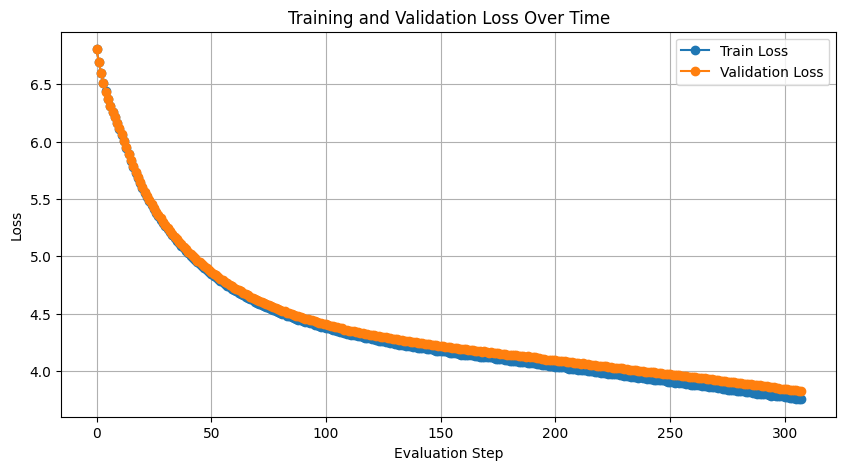

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

# 001_000: train_loss=4.38, validation_loss=4.41

In [10]:
for iteration in range(max_iters+1, max_iters*3+1):
    if iteration % eval_interval == 0 or iteration == max_iters:
        losses = estimate_loss(eval_iters)
        print("step {:07_}: train_loss={:.3f}, validation_loss={:.3f}".format(
            iteration, losses['train'], losses['val'],
        ))

        train_losses.append(losses['train'])
        val_losses.append(losses['val'])

    x_batch, y_batch = get_batch('train')
    logits, loss = model(x_batch, y_batch)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if iteration % save_interval != 0:
        continue

    checkpoint_pt = str(checkpoint_dir / f"checkpoint_{iteration:06}.pt")
    checkpoint = {
        
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': iteration,
        'loss': loss.item(),
    }

    torch.save(checkpoint, checkpoint_pt)
    print(f"{now()} saved checkpoint: {checkpoint_pt}")

step 1010: train_loss=4.326, validation_loss=4.357
step 1020: train_loss=4.322, validation_loss=4.357
step 1030: train_loss=4.318, validation_loss=4.351
step 1040: train_loss=4.313, validation_loss=4.348
step 1050: train_loss=4.310, validation_loss=4.345
step 1060: train_loss=4.308, validation_loss=4.342
step 1070: train_loss=4.302, validation_loss=4.338
step 1080: train_loss=4.302, validation_loss=4.333
step 1090: train_loss=4.293, validation_loss=4.331
step 1100: train_loss=4.290, validation_loss=4.325
step 1110: train_loss=4.284, validation_loss=4.319
step 1120: train_loss=4.283, validation_loss=4.316
step 1130: train_loss=4.277, validation_loss=4.315
step 1140: train_loss=4.274, validation_loss=4.309
step 1150: train_loss=4.270, validation_loss=4.303
step 1160: train_loss=4.264, validation_loss=4.302
step 1170: train_loss=4.261, validation_loss=4.299
step 1180: train_loss=4.258, validation_loss=4.292
step 1190: train_loss=4.253, validation_loss=4.292
step 1200: train_loss=4.247, va

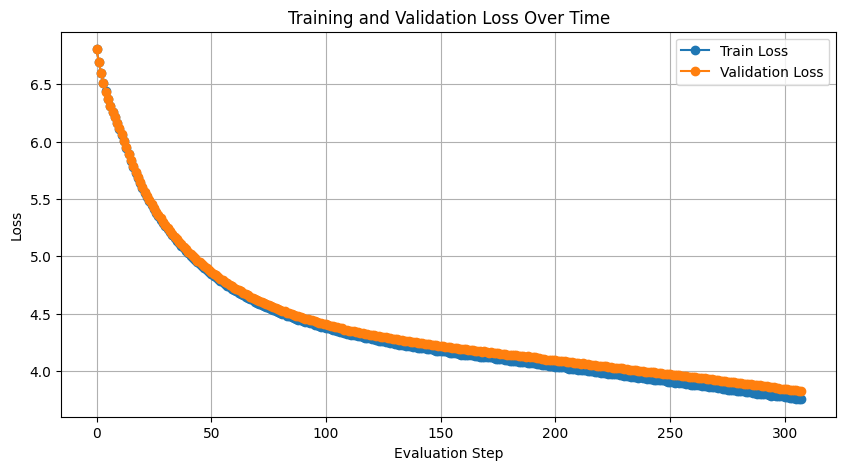

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

# 001_000: train_loss=4.38, validation_loss=4.41
# 003_000: train_loss=3.75, validation_loss=3.82

In [15]:
for iteration in range(3*max_iters+1, 5*max_iters+1):
    if iteration % eval_interval == 0 or iteration == max_iters:
        losses = estimate_loss(eval_iters)
        print("step {:07_}: train_loss={:.3f}, validation_loss={:.3f}".format(
            iteration, losses['train'], losses['val'],
        ))

        train_losses.append(losses['train'])
        val_losses.append(losses['val'])

    x_batch, y_batch = get_batch('train')
    logits, loss = model(x_batch, y_batch)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if iteration % save_interval != 0:
        continue

    checkpoint_pt = str(checkpoint_dir / f"checkpoint_{iteration:06}.pt")
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': iteration,
        'loss': loss.item(),
    }

    torch.save(checkpoint, checkpoint_pt)
    print("--> saved checkpoint: {checkpoint_pt}")

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

# 001_000: train_loss=4.38, validation_loss=4.41
# 003_000: train_loss=3.75, validation_loss=3.82
# 005_000: train_loss=3.37, validation_loss=3.47

step 3010: train_loss=3.747, validation_loss=3.816
step 3020: train_loss=3.743, validation_loss=3.814
step 3030: train_loss=3.739, validation_loss=3.807
step 3040: train_loss=3.740, validation_loss=3.807
step 3050: train_loss=3.736, validation_loss=3.805
step 3060: train_loss=3.729, validation_loss=3.802
step 3070: train_loss=3.730, validation_loss=3.800
step 3080: train_loss=3.727, validation_loss=3.797
step 3090: train_loss=3.725, validation_loss=3.798
step 3100: train_loss=3.718, validation_loss=3.794
step 3110: train_loss=3.719, validation_loss=3.791
step 3120: train_loss=3.718, validation_loss=3.791
step 3130: train_loss=3.716, validation_loss=3.789
step 3140: train_loss=3.714, validation_loss=3.786
step 3150: train_loss=3.707, validation_loss=3.778
step 3160: train_loss=3.706, validation_loss=3.775
step 3170: train_loss=3.703, validation_loss=3.774
step 3180: train_loss=3.701, validation_loss=3.766
step 3190: train_loss=3.695, validation_loss=3.765
step 3200: train_loss=3.690, va

In [17]:
for iteration in range(5*max_iters+1, 10*max_iters+1):
    if iteration % eval_interval == 0 or iteration == max_iters:
        losses = estimate_loss(eval_iters)
        print("step {:07_}: train_loss={:.3f}, validation_loss={:.3f}".format(
            iteration, losses['train'], losses['val'],
        ))

        train_losses.append(losses['train'])
        val_losses.append(losses['val'])

    x_batch, y_batch = get_batch('train')
    logits, loss = model(x_batch, y_batch)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if iteration % save_interval != 0:
        continue

    checkpoint_pt = str(checkpoint_dir / f"checkpoint_{iteration:06}.pt")
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': iteration,
        'loss': loss.item(),
    }

    torch.save(checkpoint, checkpoint_pt)
    print("--> saved checkpoint: {checkpoint_pt}")

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

# 001_000: train_loss=4.38, validation_loss=4.41
# 003_000: train_loss=3.75, validation_loss=3.82
# 005_000: train_loss=3.37, validation_loss=3.47
# 010_000: train_loss=3.08, validation_loss=3.21

step 5010: train_loss=3.373, validation_loss=3.472
step 5020: train_loss=3.374, validation_loss=3.466
step 5030: train_loss=3.374, validation_loss=3.469
step 5040: train_loss=3.372, validation_loss=3.468
step 5050: train_loss=3.370, validation_loss=3.469
step 5060: train_loss=3.369, validation_loss=3.471
step 5070: train_loss=3.369, validation_loss=3.468
step 5080: train_loss=3.364, validation_loss=3.465
step 5090: train_loss=3.364, validation_loss=3.462
step 5100: train_loss=3.363, validation_loss=3.465
step 5110: train_loss=3.366, validation_loss=3.462
step 5120: train_loss=3.361, validation_loss=3.467
step 5130: train_loss=3.360, validation_loss=3.457
step 5140: train_loss=3.360, validation_loss=3.455
step 5150: train_loss=3.358, validation_loss=3.460
step 5160: train_loss=3.358, validation_loss=3.459
step 5170: train_loss=3.354, validation_loss=3.457
step 5180: train_loss=3.355, validation_loss=3.453
step 5190: train_loss=3.349, validation_loss=3.451
step 5200: train_loss=3.354, va

In [ ]:
for iteration in range(10*max_iters+1, 15*max_iters+1):
    if iteration % eval_interval == 0 or iteration == max_iters:
        losses = estimate_loss(eval_iters)
        print("step {:07_}: train_loss={:.3f}, validation_loss={:.3f}".format(
            iteration, losses['train'], losses['val'],
        ))

        train_losses.append(losses['train'])
        val_losses.append(losses['val'])

    x_batch, y_batch = get_batch('train')
    logits, loss = model(x_batch, y_batch)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if iteration % save_interval != 0:
        continue

    checkpoint_pt = str(checkpoint_dir / f"checkpoint_{iteration:06}.pt")
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': iteration,
        'loss': loss.item(),
    }

    torch.save(checkpoint, checkpoint_pt)
    print("--> saved checkpoint: {checkpoint_pt}")

# 001_000: train_loss=4.38, validation_loss=4.41
# 003_000: train_loss=3.75, validation_loss=3.82
# 005_000: train_loss=3.37, validation_loss=3.47
# 010_000: train_loss=3.08, validation_loss=3.21
# 015_000: train_loss=None, validation_loss=None

step 010010: train_loss=3.073, validation_loss=3.205
step 010020: train_loss=3.077, validation_loss=3.209
step 010030: train_loss=3.073, validation_loss=3.200
step 010040: train_loss=3.077, validation_loss=3.206
step 010050: train_loss=3.069, validation_loss=3.204
step 010060: train_loss=3.070, validation_loss=3.198
step 010070: train_loss=3.076, validation_loss=3.210
step 010080: train_loss=3.074, validation_loss=3.204
step 010090: train_loss=3.074, validation_loss=3.206
step 010100: train_loss=3.073, validation_loss=3.204
step 010110: train_loss=3.075, validation_loss=3.206
step 010120: train_loss=3.072, validation_loss=3.205
step 010130: train_loss=3.067, validation_loss=3.204
step 010140: train_loss=3.075, validation_loss=3.203
step 010150: train_loss=3.070, validation_loss=3.199
step 010160: train_loss=3.071, validation_loss=3.200
step 010170: train_loss=3.068, validation_loss=3.199
step 010180: train_loss=3.066, validation_loss=3.200
step 010190: train_loss=3.065, validation_loss

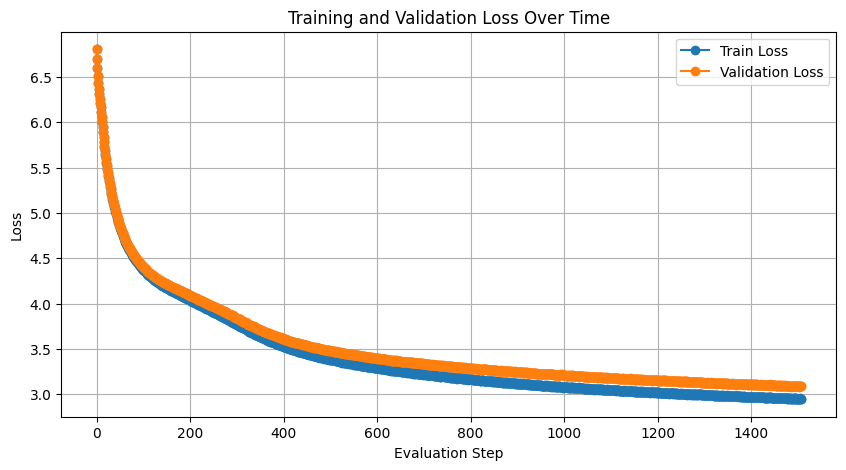

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()